In [1]:
        import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid",font_scale = 1.2)

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
#数据读取
df = pd.read_parquet('user_behavior_cleaned_dataset.parquet')
print(df.head(5))

   user_id  item_id  category_id behavior_type           timestamp       date
0  1000169  1328010       959452            pv 2017-09-11 08:16:39 2017-09-11
1   112815  2489903      1487591            pv 2017-11-06 10:44:52 2017-11-06
2   108233  4336503      3531700            pv 2017-11-10 13:33:35 2017-11-10
3   114678  3662082      1080785            pv 2017-11-12 06:19:40 2017-11-12
4    12775  2897780       886203            pv 2017-11-12 22:37:24 2017-11-13


In [3]:
result_pv = df[df['behavior_type'] == 'pv']
result_fav = df[df['behavior_type'] == 'fav']
result_cart = df[df['behavior_type'] == 'cart']
result_buy = df[df['behavior_type'] == 'buy']

count_pv = result_pv['user_id'].nunique()
count_fav = result_fav['user_id'].nunique()
count_cart = result_cart['user_id'].nunique()
count_buy = result_buy['user_id'].nunique()

print(f"浏览用户{count_pv},其中收藏有{count_fav}人,有{count_cart}人加入购物车,{count_buy}人购买,"
      f"收藏转化率{count_fav/count_pv:.2%},加够转化率{count_cart/count_pv:.2%},支付转化率{count_buy/count_pv:.2%}")

浏览用户10169,其中收藏有4070人,有7665人加入购物车,7000人购买,收藏转化率40.02%,加够转化率75.38%,支付转化率68.84%


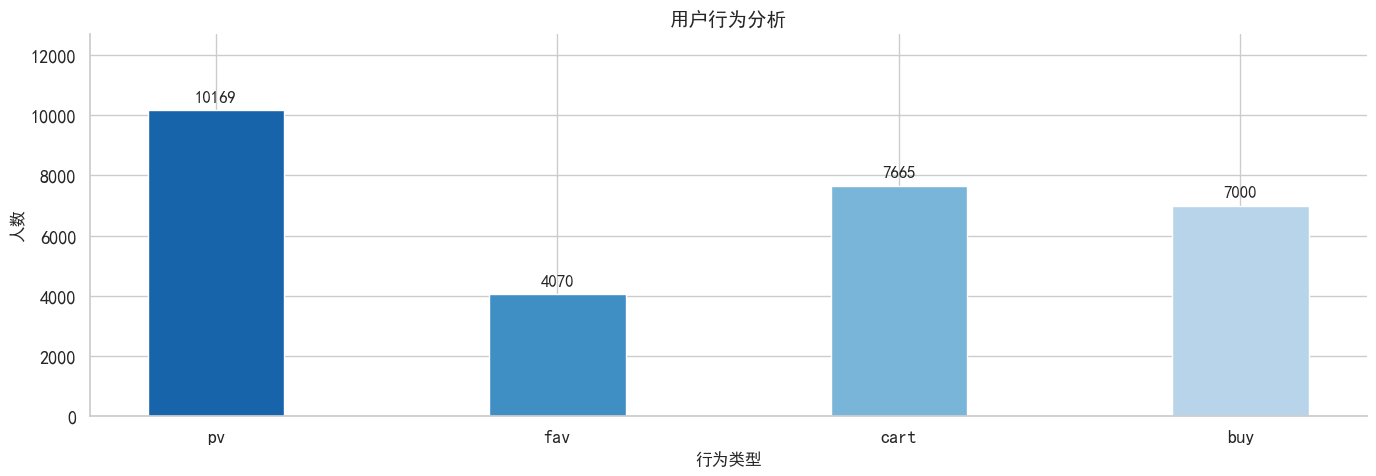

In [4]:
df_ratio = pd.DataFrame({
      '行为':['pv','fav','cart','buy'],
      '人数':[count_pv,count_fav,count_cart,count_buy]
})
fig,axes = plt.subplots(figsize=(14,5))
colors = plt.cm.Blues(np.linspace(0.8,0.3,len(df_ratio)))
axes.bar(df_ratio['行为'],df_ratio['人数'],color = colors,width=0.4)
for i,(behavior,count) in enumerate(zip(df_ratio['行为'],df_ratio['人数'])):
    axes.text(i,count + max(df_ratio['人数']) * 0.02,
              f'{count:.0f}',
              ha = 'center',
              va = 'bottom',
              fontsize = 12,
              fontweight = 'bold',
              )
axes.set_title('用户行为分析',fontsize=14)
axes.set_xlabel('行为类型',fontsize=12)
axes.set_ylabel('人数',fontsize=12)
axes.set_ylim([0,max(df_ratio['人数'])*1.25])

sns.despine()

plt.tight_layout()
plt.savefig('traffic_funnel_analysis.png',dpi=300)